# Sum of Square Spectral Amplification Resource Estimation

This notebook demonstrates how to use QDK Chemistry to construct a Sum of Squares Spectral Amplification (SOSSA) block-encoding circuit and perform resource estimation using QRE v3.
The goal is to enable users to understand and further improve on the fault-tolerant resource requirements of state-of-the-art quantum algorithms.

In addition to [installing `qdk-chemistry`](https://github.com/microsoft/qdk-chemistry/blob/main/INSTALL.md), you will need to install the `jupyter` and `qre` extras to run this notebook:

```bash
pip install 'qdk-chemistry[jupyter,qre]'
```

In [10]:
# Reduce logging output for demo
from qdk_chemistry.utils import Logger
Logger.set_global_level(Logger.LogLevel.off)

## Load a DFTHC factorized Hamiltonian for H2

Load DFTHC tensors from a `.dfthc.json` file and construct a `FactorizedHamiltonianContainer`.
The JSON uses the same field names as the C++ serialization format (`one_body_integrals`, `u_matrices`, `w_matrices`, `wb_matrix`).

In [11]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from qdk_chemistry.algorithms.controlled_circuit_mapper.sossa_mapper import SOSSAMapper
from qdk_chemistry.algorithms.hamiltonian_unitary_builder.block_encoding.sossa import SOSSABuilder
from qdk_chemistry.data import AlgorithmRef, BasisSet, FactorizedHamiltonianContainer, Hamiltonian, Orbitals, OrbitalType, Shell
from qdk_chemistry.data.controlled_unitary import ControlledUnitary
from qdk_chemistry.data.unitary_representation.containers.sossa import SOSSAContainer

HAM_JSON = Path("h2_factorized_r1_b2_c1.hamiltonian.json")

ham = Hamiltonian.from_json(HAM_JSON.read_text())
fh = ham.get_container()
N = fh.get_num_orbitals()
R, B, C = fh.get_num_ranks(), fh.get_num_bases(), fh.get_num_copies()
print(f"Loaded from {HAM_JSON}: N={N}, R={R}, B={B}, C={C}")

Loaded from h2_factorized_r1_b2_c1.hamiltonian.json: N=2, R=1, B=2, C=1


## Generate SOSSA Circuit

In [12]:
from qdk.widgets import Circuit
# Step 1: SOSSABuilder → UnitaryRepresentation
builder = SOSSABuilder(quantum_walk=True)
unitary_rep = builder.run(fh)
container = unitary_rep.get_container()

# Step 2: SOSSAMapper → Circuit
controlled_unitary = ControlledUnitary(unitary=unitary_rep, control_indices=[0])
mapper = SOSSAMapper()
mapper.settings().set("outer_prepare", AlgorithmRef("state_prep", "dense_pure_state"))
mapper.settings().set("inner_prepare_algorithm", "direct")
mapper.settings().set("select_algorithm", "direct")

circuit = mapper.run(controlled_unitary)
# Circuit(circuit.get_qsharp_circuit())

## Verify QPE simulation

In [13]:
from qdk_chemistry.algorithms.phase_estimation.iterative_phase_estimation import IterativePhaseEstimation
from qdk_chemistry.data import AlgorithmRef
from qdk_chemistry.data.circuit import Circuit, QsharpFactoryData
from qdk_chemistry.utils.qsharp import QSHARP_UTILS
from qdk_chemistry.algorithms.phase_estimation.standard_phase_estimation import StandardPhaseEstimation
from qdk_chemistry.algorithms.phase_estimation.circuit_builder.standard_builder import QdkStandardQpeCircuitBuilder
from qdk_chemistry.algorithms.circuit_executor.qdk import QdkSparseStateSimulator
import matplotlib.pyplot as plt
from collections import Counter

num_phase_bits_std = 4
num_system_qubits = 2 * N
hf_physical = [0] * num_system_qubits
hf_physical[0] = 1  # sysDown[0] occupied (orbital 0, spin-down)
hf_physical[N] = 1  # sysUp[0] occupied  (orbital 0, spin-up)
row_map = list(range(num_system_qubits - 1, -1, -1))
state_prep_params = {
    "rowMap": row_map,
    "stateVector": [0.0] * (2**num_system_qubits),
    "expansionOps": [],
    "numQubits": num_system_qubits,
}
hf_index = sum(hf_physical[row_map[j]] << (num_system_qubits - 1 - j) for j in range(num_system_qubits))
state_prep_params["stateVector"][hf_index] = 1.0

qsharp_factory = QsharpFactoryData(
    program=QSHARP_UTILS.StatePreparation.MakeStatePreparationCircuit,
    parameter=state_prep_params,
)
qsharp_op = QSHARP_UTILS.StatePreparation.MakeStatePreparationOp(state_prep_params)
state_prep = Circuit(qsharp_factory=qsharp_factory, qsharp_op=qsharp_op)

std_builder = QdkStandardQpeCircuitBuilder(
    num_bits=num_phase_bits_std,
    controlled_circuit_mapper=AlgorithmRef(
        "controlled_circuit_mapper", "sossa",
        outer_prepare=AlgorithmRef("state_prep", "dense_pure_state"),
        inner_prepare_algorithm="direct",
        select_algorithm="direct",
    ),
    unitary_builder=AlgorithmRef("hamiltonian_unitary_builder", "sossa", quantum_walk=True),
)
std_circuits = std_builder.run(
    state_preparation=state_prep,
    qubit_hamiltonian=fh,
)
executor = QdkSparseStateSimulator()
result = executor.run(std_circuits[0], shots=50)
counts = result.bitstring_counts
phase_counts = {}
for bitstring, count in result.bitstring_counts.items():
    phase = int(bitstring, 2) / (2**num_phase_bits_std)
    phase_counts[phase] = phase_counts.get(phase, 0) + count

labels = [f"{p:.4f}" for p in sorted(phase_counts)]
values = [phase_counts[p] for p in sorted(phase_counts)]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(labels, values, color="steelblue", edgecolor="white")
ax.set_xlabel("Measured phase φ")
ax.set_ylabel("Counts")
ax.set_title(f"Standard QPE phase distribution (50 shots, {num_phase_bits_std} bits)")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## QRE v3 Resource Estimation

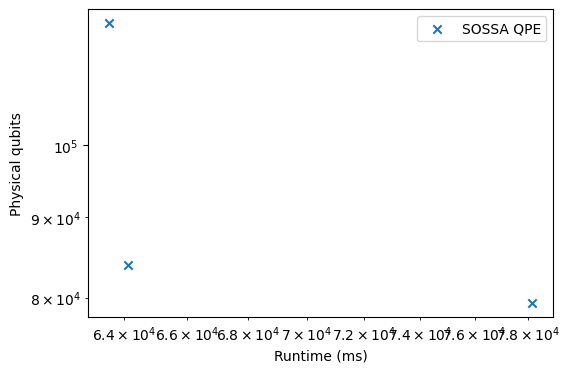

In [ ]:
from qdk_chemistry.algorithms.phase_estimation.circuit_builder.standard_builder import QdkStandardQpeCircuitBuilder
from qdk.qre import estimate, plot_estimates
from qdk.qre.models import Majorana, RoundBasedFactory, ThreeAux

# Build the full standard QPE circuit for resource estimation
num_bits_qre_std = 10

std_builder = QdkStandardQpeCircuitBuilder(
    num_bits=num_bits_qre_std,
    controlled_circuit_mapper=AlgorithmRef(
        "controlled_circuit_mapper", "sossa",
        outer_prepare=AlgorithmRef("state_prep", "alias_sampling"),
        inner_prepare_algorithm="controlled_alias_sampling",
        select_algorithm="qrom_phase_gradient",
    ),
    unitary_builder=AlgorithmRef("hamiltonian_unitary_builder", "sossa", quantum_walk=True),
)

std_circuits = std_builder.run(
    state_preparation=state_prep,
    qubit_hamiltonian=fh,
)
std_qpe_circuit = std_circuits[0]

app = std_qpe_circuit.get_qre_application()
architecture = Majorana(error_rate=1e-5)
isa_query = ThreeAux.q() * RoundBasedFactory.q(use_cache=True, code_query=ThreeAux.q())

qre_result = estimate(app, architecture, isa_query, max_error=0.01, name="SOSSA QPE")
plot_estimates(qre_result, figsize=(6, 4), runtime_unit="ms")

## Resource Estimation for Fake Data Generated based on R, B, C 

In [ ]:
import math
import time

import numpy as np
import pandas as pd

from qdk_chemistry.data import (
    AlgorithmRef,
    FactorizedHamiltonianContainer,
    ModelOrbitals,
)
from qdk_chemistry.algorithms.controlled_circuit_mapper.sossa_mapper import SOSSAMapper
from qdk_chemistry.algorithms.hamiltonian_unitary_builder.block_encoding.sossa import SOSSABuilder
from qdk_chemistry.algorithms.phase_estimation.circuit_builder.standard_builder import QdkStandardQpeCircuitBuilder
from qdk_chemistry.data.circuit import Circuit, QsharpFactoryData
from qdk_chemistry.utils.qsharp import QSHARP_UTILS
from qdk.qre import estimate
from qdk.qre.models import Majorana, RoundBasedFactory, ThreeAux

# No-op state preparation (identity on system qubits) for resource estimation
noop_state_prep = Circuit(
    qsharp_factory=QsharpFactoryData(
        program=QSHARP_UTILS.PrepSelPrep.NoOpPrepare,
        parameter={},
    ),
    qsharp_op=QSHARP_UTILS.PrepSelPrep.NoOpPrepare,
)


def make_fake_factorized_hamiltonian(N, R, B, C, seed=42):
    """Create a fake FactorizedHamiltonianContainer with given (N, R, B, C)."""
    rng = np.random.default_rng(seed)
    h1 = rng.standard_normal((N, N))
    h1 = (h1 + h1.T) / 2

    u_matrices = np.zeros(R * B * N)
    for ri in range(R):
        for bi in range(B):
            v = rng.standard_normal(N)
            v /= np.linalg.norm(v)
            u_matrices[ri * B * N + bi * N : ri * B * N + (bi + 1) * N] = v

    w_matrices = rng.standard_normal(R * B * C) * 0.1
    wb_matrix = rng.standard_normal((R, C)) * 0.1
    orbitals = ModelOrbitals(N)
    inactive_fock = np.zeros((N, N))

    return FactorizedHamiltonianContainer(
        h1, u_matrices, w_matrices, wb_matrix,
        R, B, C, orbitals, 0.0, inactive_fock,
    )


molecules = [
    ("Fe2S2-20",  dict(N=20, R=14, B=15, C=5,  b_rot=15, b_coeff=11, lambda_eff=6.4690)),
    ("Fe4S4-36",  dict(N=36, R=9,  B=18, C=18, b_rot=17, b_coeff=13, lambda_eff=14.9842)),
    ("FeMoCo-54", dict(N=54, R=10, B=27, C=27, b_rot=15, b_coeff=15, lambda_eff=21.4486)),
    ("FeMoCo-76", dict(N=76, R=15, B=57, C=19, b_rot=15, b_coeff=9,  lambda_eff=43.6538)),
    ("XVIII-56",  dict(N=56, R=5,  B=28, C=28, b_rot=12, b_coeff=7,  lambda_eff=17.0712)),
]

sigma_E = 1e-3  # 1 mHa target precision
results_rows = []
architecture = Majorana(error_rate=1e-5)
isa_query = ThreeAux.q() * RoundBasedFactory.q(use_cache=True, code_query=ThreeAux.q())

for label, params in molecules:
    N_mol, R_mol, B_mol, C_mol = params["N"], params["R"], params["B"], params["C"]
    b_rot, b_coeff = params["b_rot"], params["b_coeff"]
    num_queries = math.ceil(math.pi * params["lambda_eff"] / (2 * sigma_E))
    fh_fake = make_fake_factorized_hamiltonian(N_mol, R_mol, B_mol, C_mol)

    std_builder = QdkStandardQpeCircuitBuilder(
        num_bits=num_bits_qre_std,
        controlled_circuit_mapper=AlgorithmRef(
            "controlled_circuit_mapper", "sossa",
            outer_prepare=AlgorithmRef("state_prep", "alias_sampling"),
            inner_prepare_algorithm="controlled_alias_sampling",
            select_algorithm="qrom_phase_gradient",
        ),
        unitary_builder=AlgorithmRef("hamiltonian_unitary_builder", "sossa", quantum_walk=True),
    )
    std_circuits = std_builder.run(
        state_preparation=noop_state_prep,
        qubit_hamiltonian=fh_fake,
    )
    std_qpe_circuit = std_circuits[0]
    logical_count = std_qpe_circuit.estimate().logical_counts
    print(f"Logical counts for {label}: {logical_count}")
    app = std_qpe_circuit.get_qre_application()
    qre_result = estimate(app, architecture, isa_query, max_error=0.01, name=f"{label}")
    # # Extract from EstimationResult (first ISA row)
    if len(qre_result) == 0:
        raise ValueError("No results from resource estimation")

    r = qre_result[0] # min qubit entries
    results_rows.append(r)

Logical counts for Fe2S2-20: {'numQubits': 323, 'tCount': 777534, 'rotationCount': 6354, 'rotationDepth': 6197, 'cczCount': 58045020, 'ccixCount': 0, 'measurementCount': 57187756}
Logical counts for Fe4S4-36: {'numQubits': 566, 'tCount': 1432254, 'rotationCount': 18630, 'rotationDepth': 18473, 'cczCount': 207576930, 'ccixCount': 0, 'measurementCount': 205989244}


KeyboardInterrupt: 

In [ ]:
results_rows